# Pick/ban rate vs Champion winrate

- Gráfico: Scatter plot (Gráfico de dispersión).
- Eje X: Frecuencia de aparición (Picks + Bans). Eje Y: Winrate.
- Insight: Los campeones en la esquina superior derecha son "OP" (Overpowered). Los de la inferior derecha son trampas (muy jugados pero pierden mucho).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import PolynomialFeatures

import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*X does not have valid feature names.*')

# Pickrate

# Data read

In [2]:
año = "2024"
df = pd.read_csv(f"../Data/Raw Data/{año}_LoL_esports_match_data_from_OraclesElixir.csv",low_memory=False)

In [3]:
# Total de partidas
partidas_totales = int(df["gameid"].value_counts().sum()/12)
print(partidas_totales)

10192


In [4]:
# Mantener solo los jugadores (participantes 1-10)
df = df[df["participantid"].between(1, 10)]

In [5]:
# Frecuencia de aparición de cada campeón
apariciones = df["champion"].value_counts()

In [6]:
#% de pickrate del campeon
pickrate = lambda partidas, campeon: round((campeon / partidas) * 100, 2)

In [7]:
estadisticas_picks = pd.DataFrame({
    "Apariciones": apariciones,
    "Pickrate": pickrate(partidas_totales,apariciones)
}).fillna(0)

In [8]:
# Ordenar por frecuencia de aparición
estadisticas_picks = estadisticas_picks.sort_values(by="Apariciones", ascending=False)

# Posiciones del eje X
x = np.arange(len(estadisticas_picks))

In [9]:
print(estadisticas_picks)

          Apariciones  Pickrate
champion                       
Rell             3834     37.62
Nautilus         3828     37.56
K'Sante          3773     37.02
Varus            2685     26.34
Corki            2512     24.65
...               ...       ...
Shaco               6      0.06
Rammus              6      0.06
Singed              6      0.06
Teemo               3      0.03
Fizz                2      0.02

[168 rows x 2 columns]


In [10]:
estadisticas_picks.to_csv("../Data/Stadistics/champions_pick_rate.csv")

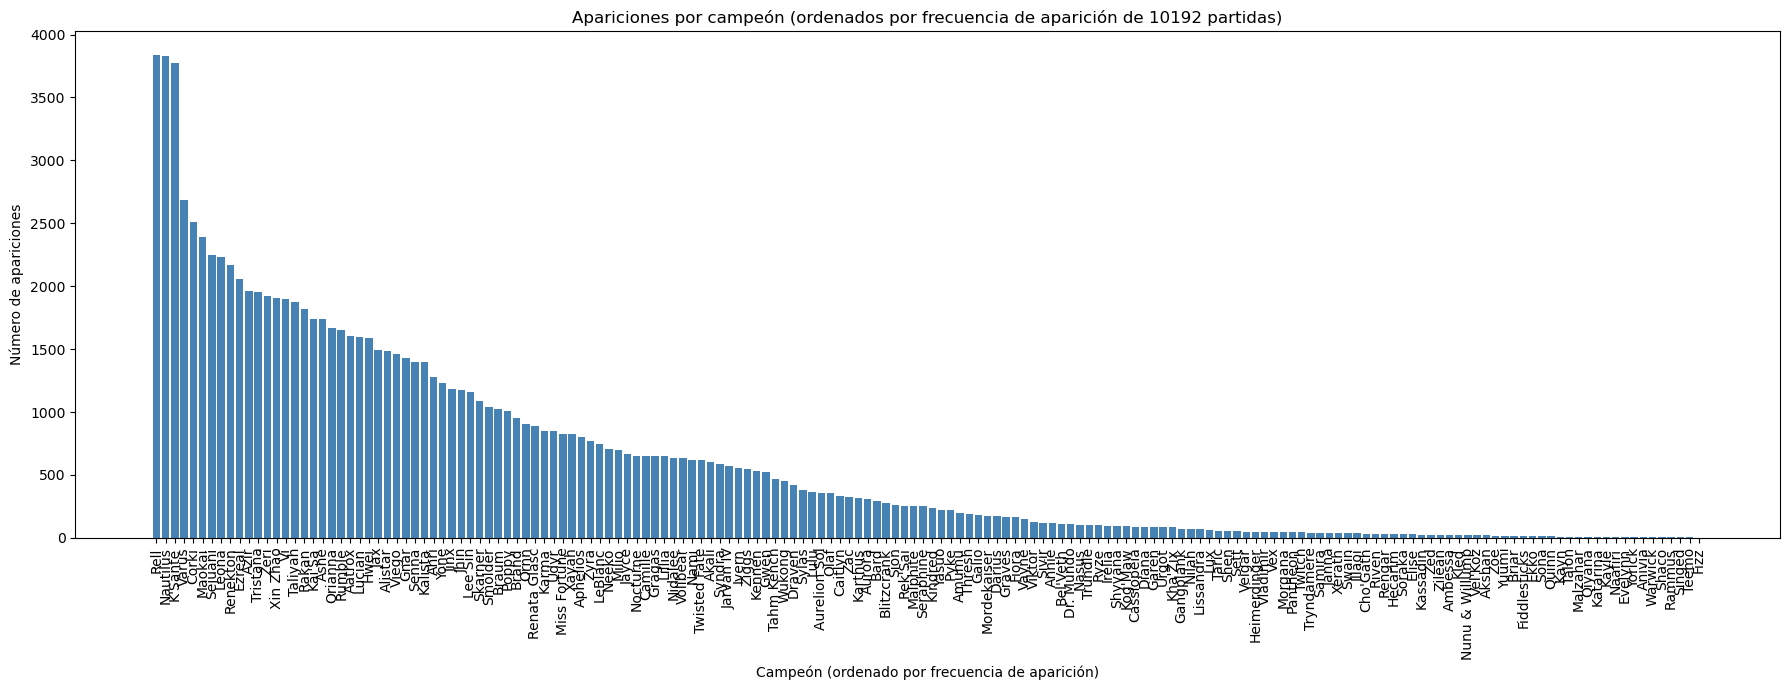

In [11]:
plt.figure(figsize=(18,7))
plt.bar(x, estadisticas_picks["Apariciones"], color="steelblue")

plt.xticks(x, estadisticas_picks.index, rotation=90)
plt.xlabel("Campeón (ordenado por frecuencia de aparición)")
plt.ylabel("Número de apariciones")
plt.title(f"Apariciones por campeón (ordenados por frecuencia de aparición de {partidas_totales} partidas)")

plt.tight_layout()
plt.show()

          Apariciones   Pick
champion                    
Fizz                2   0.02
Teemo               3   0.03
Singed              6   0.06
Shaco               6   0.06
Rammus              6   0.06
...               ...    ...
Corki            2512  24.65
Varus            2685  26.34
K'Sante          3773  37.02
Nautilus         3828  37.56
Rell             3834  37.62

[168 rows x 2 columns]


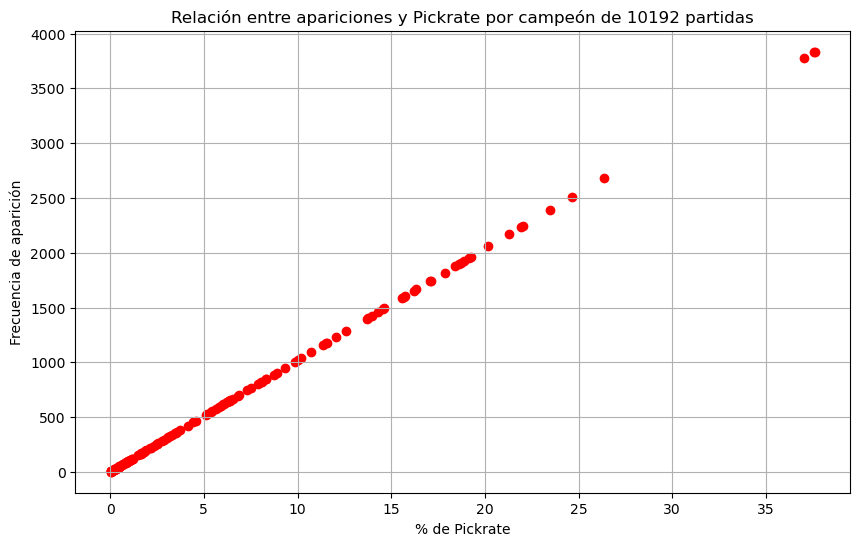

In [12]:
scatter_estadisticas = df.groupby("champion").agg(
    Apariciones=("champion", "count")
)

Pick = pickrate(partidas_totales, scatter_estadisticas["Apariciones"])
scatter_estadisticas["Pick"] = Pick
print(scatter_estadisticas.sort_values(by="Pick"))
plt.figure(figsize=(10,6))
plt.scatter(
    scatter_estadisticas["Pick"],
    scatter_estadisticas["Apariciones"],
    color="red"
)

plt.xlabel("% de Pickrate")
plt.ylabel("Frecuencia de aparición")
plt.title(f"Relación entre apariciones y Pickrate por campeón de {partidas_totales} partidas")
plt.grid(True)

plt.show()

# Winrate

# Data read

In [13]:
año = "2024"
df = pd.read_csv(f"../Data/Raw Data/{año}_LoL_esports_match_data_from_OraclesElixir.csv",low_memory=False)

In [14]:
# Total de partidas
partidas_totales = int(df["gameid"].value_counts().sum()/12)
print(partidas_totales)

10192


In [15]:
# Mantener solo los jugadores (participantes 1-10)
df = df[df["participantid"].between(1, 10)]

In [16]:
# Frecuencia de aparición de cada campeón
apariciones = df["champion"].value_counts()

In [17]:
# Victorias por campeón
victorias = (
    df.groupby("champion")["result"]
      .sum()
)

In [18]:
#% de winrate del campeon
winrate = lambda apar, vict: round((vict / apar) * 100, 2)

In [19]:
# Crear DataFrame con ambas métricas
estadisticas_wins = pd.DataFrame({
    "Apariciones": apariciones,
    "Victorias": victorias,
    "Winrate": winrate(apariciones,victorias)
}).fillna(0)

In [20]:
# Ordenar por frecuencia de aparición
estadisticas_wins = estadisticas_wins.sort_values(by="Apariciones", ascending=False)

# Posiciones del eje X
x = np.arange(len(estadisticas_wins))

In [21]:
print(estadisticas_wins)

          Apariciones  Victorias  Winrate
champion                                 
Rell             3834       2000    52.16
Nautilus         3828       1910    49.90
K'Sante          3773       1854    49.14
Varus            2685       1289    48.01
Corki            2512       1226    48.81
...               ...        ...      ...
Rammus              6          2    33.33
Shaco               6          3    50.00
Singed              6          2    33.33
Teemo               3          1    33.33
Fizz                2          0     0.00

[168 rows x 3 columns]


In [22]:
estadisticas_wins.to_csv("../Data/Stadistics/champions_win_rate.csv")

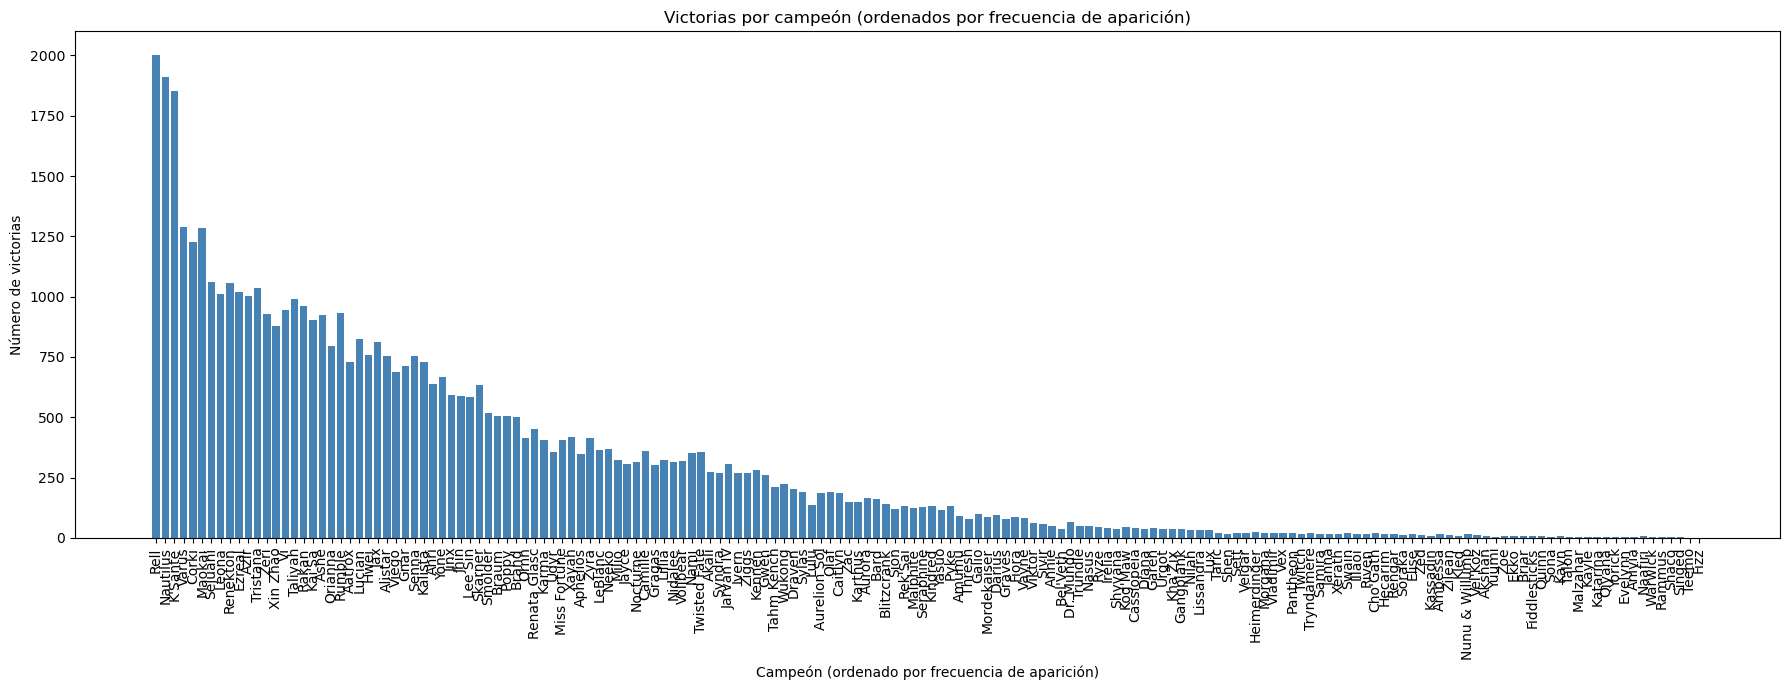

In [23]:
# Crear gráfico
plt.figure(figsize=(18,7))
plt.bar(x, estadisticas_wins["Victorias"], color="steelblue")

plt.xticks(x, estadisticas_wins.index, rotation=90)
plt.xlabel("Campeón (ordenado por frecuencia de aparición)")
plt.ylabel("Número de victorias")
plt.title("Victorias por campeón (ordenados por frecuencia de aparición)")

plt.tight_layout()
plt.show()

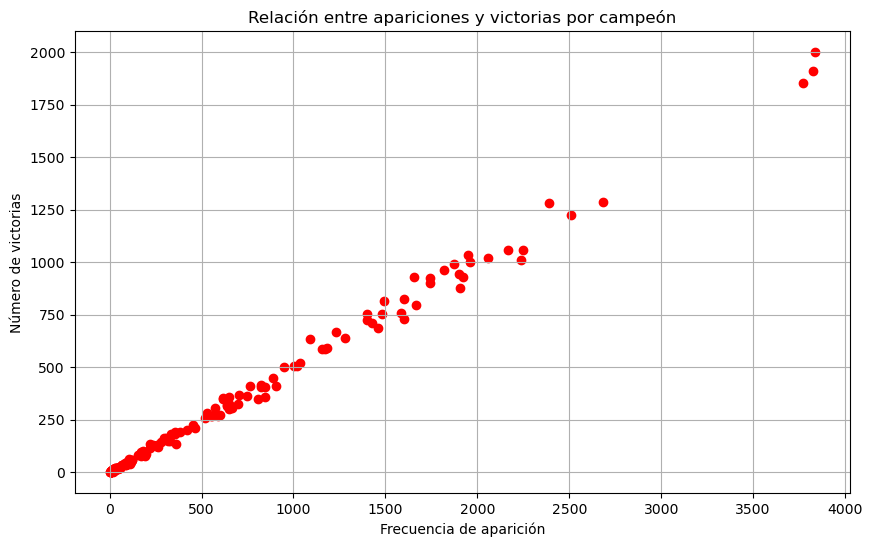

In [24]:
scatter_estadisticas = df.groupby("champion").agg(
    Apariciones=("champion", "count"),
    Victorias=("result", "sum")
)

plt.figure(figsize=(10,6))
plt.scatter(
    scatter_estadisticas["Apariciones"],
    scatter_estadisticas["Victorias"],
    color="red"
)

plt.xlabel("Frecuencia de aparición")
plt.ylabel("Número de victorias")
plt.title("Relación entre apariciones y victorias por campeón")
plt.grid(True)

plt.show()

                Apariciones  Victorias    Win
champion                                     
Fizz                      2          0   0.00
Yuumi                    16          3  18.75
Kled                     23          6  26.09
Warwick                   7          2  28.57
Malzahar                 10          3  30.00
...                     ...        ...    ...
Elise                    28         18  64.29
Briar                    14          9  64.29
Ekko                     14          9  64.29
Nunu & Willump           21         14  66.67
Naafiri                   8          7  87.50

[168 rows x 3 columns]


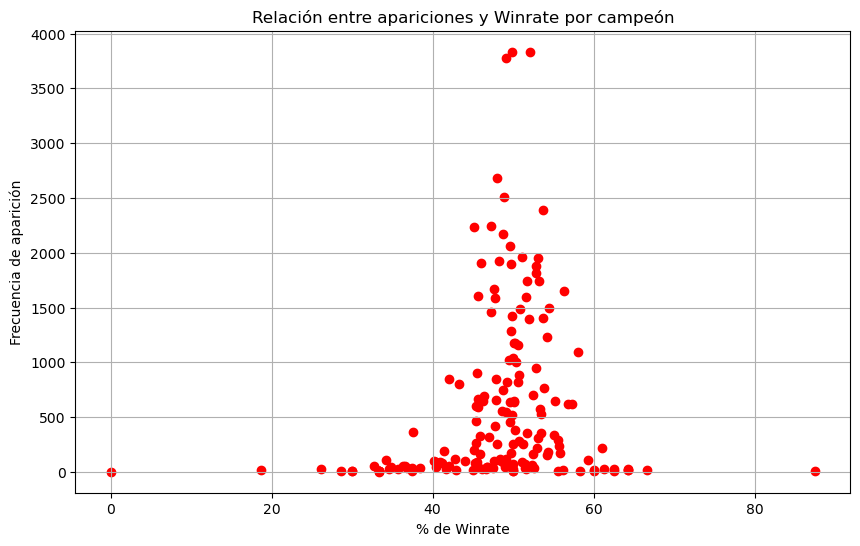

In [25]:
scatter_estadisticas = df.groupby("champion").agg(
    Apariciones=("champion", "count"),
    Victorias=("result", "sum")
)

Win = winrate(scatter_estadisticas["Apariciones"], scatter_estadisticas["Victorias"])
scatter_estadisticas["Win"] = Win
print(scatter_estadisticas.sort_values(by="Win"))
plt.figure(figsize=(10,6))
plt.scatter(
    scatter_estadisticas["Win"],
    scatter_estadisticas["Apariciones"],
    color="red"
)

plt.xlabel("% de Winrate")
plt.ylabel("Frecuencia de aparición")
plt.title("Relación entre apariciones y Winrate por campeón")
plt.grid(True)

plt.show()

# Banrate

# Data read

In [26]:
año = "2024"
df = pd.read_csv(f"../Data/Raw Data/{año}_LoL_esports_match_data_from_OraclesElixir.csv",low_memory=False)

In [27]:
# Total de partidas
partidas_totales = int(df["gameid"].value_counts().sum()/12)
print(partidas_totales)

10192


In [28]:
df = df[df["participantid"].between(100, 200)]

In [29]:
partidas_totales = df["gameid"].value_counts().sum()/2
print(partidas_totales)

10192.0


In [30]:
# Todos los bans de cada campeón
columnas_baneos = ["ban1","ban2","ban3","ban4","ban5"]

obtener_baneos = df[columnas_baneos].melt(value_name='Camp')
obtener_baneos.drop("variable", axis = 1, inplace=True)
obtener_baneos = obtener_baneos.value_counts().reset_index()
obtener_baneos.columns = ['Camp', 'Bans']
#obtener_baneos.set_index("Camp", inplace=True)
print(obtener_baneos)

#bans = pd.DataFrame({
#    "Campeones": camp_baneds,
#    "Bans": bans,
#    "Banrate": banrate(apariciones,victorias)
#}).fillna(0).set_index("Campeones")

          Camp  Bans
0         Ashe  4776
1       Rumble  4508
2      Kalista  3590
3           Vi  2927
4     Tristana  2699
..         ...   ...
162       Fizz     3
163   Malzahar     2
164      Teemo     2
165  Master Yi     1
166     Qiyana     1

[167 rows x 2 columns]


In [31]:
#% de banrate del campeon
banrate = lambda partidas, baneos: round((baneos / partidas) * 100, 2)

In [32]:
estadisticas_bans = pd.DataFrame({
    "Campeón": obtener_baneos["Camp"],
    "Baneos": obtener_baneos["Bans"],
    "Banrate": banrate(partidas_totales,obtener_baneos["Bans"])
}).fillna(0)
estadisticas_bans.set_index("Campeón", inplace=True)

In [33]:
# Ordenar por frecuencia de baneo
estadisticas_bans = estadisticas_bans.sort_values(by="Baneos", ascending=False)

# Posiciones del eje X
x = np.arange(len(estadisticas_bans))

In [34]:
print(estadisticas_bans)

           Baneos  Banrate
Campeón                   
Ashe         4776    46.86
Rumble       4508    44.23
Kalista      3590    35.22
Vi           2927    28.72
Tristana     2699    26.48
...           ...      ...
Fizz            3     0.03
Malzahar        2     0.02
Teemo           2     0.02
Master Yi       1     0.01
Qiyana          1     0.01

[167 rows x 2 columns]


In [35]:
estadisticas_bans.to_csv("../Data/Stadistics/champions_ban_rate.csv")